# Setup
In this section, we will install and set our paths to our dataset. We first install the libraries. Each library is mentioned with its specified reason:
- `os` - to 
- `matplotlib` - to display the images before processing, after processing

In [5]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

After this, we will set our paths accordingly to point to the train, valid and test folders.

In [6]:
dataset_path = Path('/Users/tharshensurianbalan/Coding/uni-subjects/machine-learning/assignment/dataset')
training_data_path = dataset_path / 'train'
validation_data_path = dataset_path / 'valid'
testing_data_path = dataset_path / 'test'

# Verify the paths
print(f"Dataset path exists: {dataset_path.exists()}")
print(f"Training path exists: {training_data_path.exists()}")
print(f"Validation path exists: {validation_data_path.exists()}")
print(f"Testing path exists: {testing_data_path.exists()}")

Dataset path exists: True
Training path exists: True
Validation path exists: True
Testing path exists: True


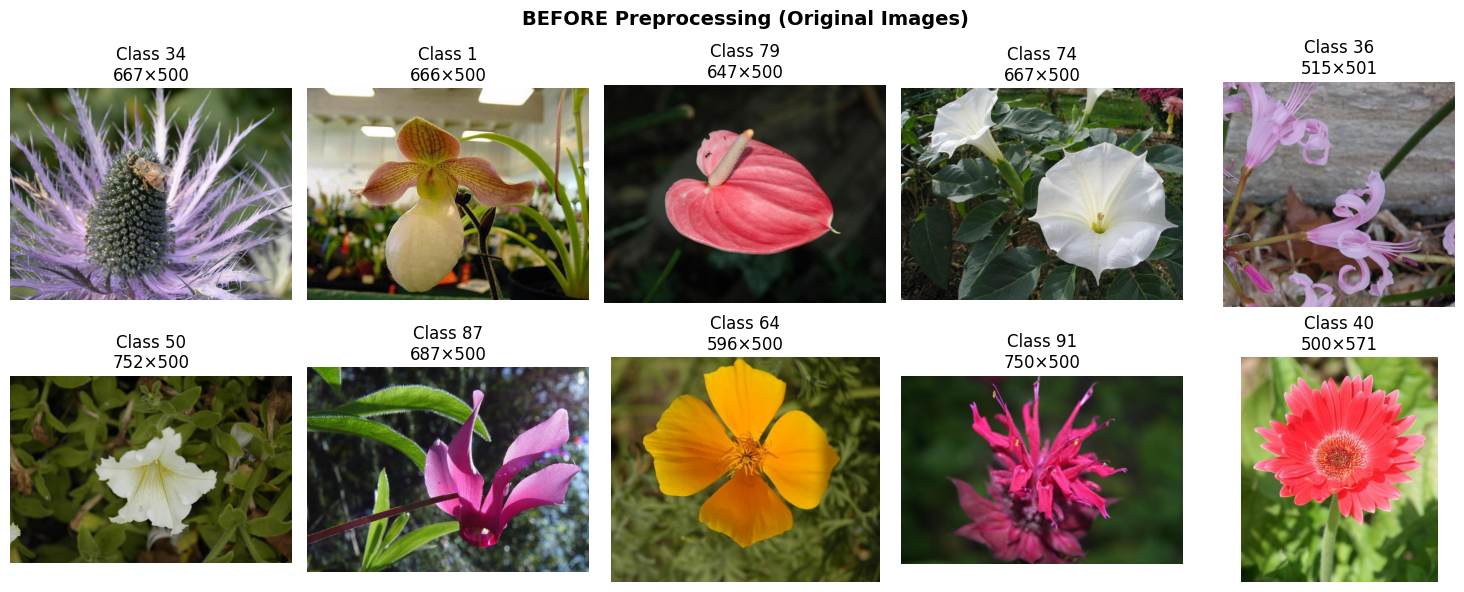

Original image properties:
  - Various sizes (not standardized)
  - RGB format (3 channels)
  - Pixel values: 0-255


In [59]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Get 10 random images from training set (original, unprocessed)
np.random.seed(10)
all_image_paths = []
all_labels = []

for label, folder in enumerate(sorted(training_data_path.iterdir(), key=lambda x: int(x.name))):
    if folder.is_dir():
        for img_path in folder.glob('*.jpg'):
            all_image_paths.append(img_path)
            all_labels.append(label)

random_indices = np.random.choice(len(all_image_paths), 10, replace=False)

for idx, ax in enumerate(axes):
    img_idx = random_indices[idx]
    img = Image.open(all_image_paths[img_idx])
    ax.imshow(img)
    ax.set_title(f"Class {all_labels[img_idx]}\n{img.size[0]}×{img.size[1]}")
    ax.axis('off')

plt.suptitle("BEFORE Preprocessing (Original Images)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Original image properties:")
print("  - Various sizes (not standardized)")
print("  - RGB format (3 channels)")
print("  - Pixel values: 0-255")

# Verification Step
After installing and setting up the folder paths, we will need to inspect and understand our dataset. From there, we will need to process our data to see if there's any issues with it such as defected or corrupted images.

## Count number of images
In our given dataset, it is split across 3 different folders. We have our training set, validation set and our test set. Our training set and validation set contains several folders. These folders are our classes, representing our type of plants.

In [7]:
def count_images_per_class(data_dir):
    """Count the number of images in each class folder."""
    class_counts = {}
    for class_folder in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_folder)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_folder] = num_images
    return class_counts

def count_images_flat(data_dir):
    return len([
        f for f in os.listdir(data_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

In [8]:
# Count images in each split
# For the test set, we will use the count from check_corrupted_images if it doesn't have class subfolders.
# The test_counts will be 0 if there are no subdirectories.
train_counts = count_images_per_class(training_data_path)
valid_counts = count_images_per_class(validation_data_path)
test_counts = count_images_per_class(testing_data_path)
test_image_count = count_images_flat(testing_data_path)

print(f"Training set: {sum(train_counts.values())} images across {len(train_counts)} classes")
print(f"Validation set: {sum(valid_counts.values())} images across {len(valid_counts)} classes")
print(f"Test set: {test_image_count} images (no class subfolders)")


Training set: 6552 images across 102 classes
Validation set: 818 images across 102 classes
Test set: 819 images (no class subfolders)


## Check for corrupted images
It's possible for our dataset to include corrupt or defected images. We need to verify if this is or isn't the case.

In [9]:
def check_corrupted_images(folder_path):
    """
    Scan all images in a folder and check if they can be opened.
    Returns lists of valid and corrupted image paths.
    """
    valid_images = []
    corrupted_images = []

    # Walk through all subfolders (class folders)
    for root, directories, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    # Try to open and verify the image
                    with Image.open(img_path) as img:
                        img.verify()  # This checks if file is corrupted
                    valid_images.append(img_path)
                except Exception as e:
                    corrupted_images.append((img_path, str(e)))

    return valid_images, corrupted_images

In [10]:
# Run on each split
print("Checking TRAIN folder...")
train_valid, train_corrupted = check_corrupted_images(training_data_path)
print(f"  Valid: {len(train_valid)}, Corrupted: {len(train_corrupted)}")

print("Checking VALID folder...")
valid_valid, valid_corrupted = check_corrupted_images(validation_data_path)
print(f"  Valid: {len(valid_valid)}, Corrupted: {len(valid_corrupted)}")

print("Checking TEST folder...")
test_valid, test_corrupted = check_corrupted_images(testing_data_path)
print(f"  Valid: {len(test_valid)}, Corrupted: {len(test_corrupted)}")

# Show corrupted files if any
if train_corrupted:
    print("\n⚠️ Corrupted files in TRAIN:")
    for path, error in train_corrupted:
        print(f"  {path}: {error}")

Checking TRAIN folder...
  Valid: 6552, Corrupted: 0
Checking VALID folder...
  Valid: 818, Corrupted: 0
Checking TEST folder...
  Valid: 819, Corrupted: 0


In [11]:
def check_flipped_images(folder_path):
    """
    Scans images for EXIF orientation tags which indicate the image 
    might be rotated or flipped.
    """
    flipped_count = 0
    total_images = 0
    affected_files = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        # EXIF tag 274 is 'Orientation'
                        exif = img._getexif()
                        if exif and 274 in exif:
                            orientation = exif[274]
                            # Orientations 2-8 imply some form of flipping or rotation
                            if orientation > 1:
                                flipped_count += 1
                                affected_files.append(img_path)
                except (AttributeError, KeyError, IndexError):
                    # No EXIF data found, assuming image is standard
                    pass
                except Exception as e:
                    print(f"Error checking {img_path}: {e}")

    print(f"Folder: {folder_path}")
    print(f"  - Total images scanned: {total_images}")
    print(f"  - Flipped/Rotated images detected: {flipped_count}")
    return affected_files

# Run the check on all paths
print("Checking for orientation issues...")
train_flipped = check_flipped_images(training_data_path)
valid_flipped = check_flipped_images(validation_data_path)
test_flipped = check_flipped_images(testing_data_path)

Checking for orientation issues...
Folder: /Users/tharshensurianbalan/Coding/uni-subjects/machine-learning/assignment/dataset/train
  - Total images scanned: 6552
  - Flipped/Rotated images detected: 0
Folder: /Users/tharshensurianbalan/Coding/uni-subjects/machine-learning/assignment/dataset/valid
  - Total images scanned: 818
  - Flipped/Rotated images detected: 0
Folder: /Users/tharshensurianbalan/Coding/uni-subjects/machine-learning/assignment/dataset/test
  - Total images scanned: 819
  - Flipped/Rotated images detected: 0


## Get image statistics

In [12]:
def get_image_stats(folder_path):
    """
    Collect dimension and file size statistics for all images.
    """
    dimensions = []
    file_sizes = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        dimensions.append(img.size)  # (width, height)
                    file_sizes.append(os.path.getsize(img_path))
                except:
                    pass

    return dimensions, file_sizes

In [13]:
# Get stats for training set
dimensions, file_sizes = get_image_stats(training_data_path)

widths = [d[0] for d in dimensions]
heights = [d[1] for d in dimensions]

print("=" * 50)
print("IMAGE DIMENSION STATISTICS (Training Set)")
print("=" * 50)
print(f"Total images: {len(dimensions)}")
print(f"\nWidth:")
print(f"  Min: {min(widths)} px")
print(f"  Max: {max(widths)} px")
print(f"  Mean: {np.mean(widths):.1f} px")
print(f"\nHeight:")
print(f"  Min: {min(heights)} px")
print(f"  Max: {max(heights)} px")
print(f"  Mean: {np.mean(heights):.1f} px")
print(f"\nFile size:")
print(f"  Min: {min(file_sizes)/1024:.1f} KB")
print(f"  Max: {max(file_sizes)/1024:.1f} KB")
print(f"  Mean: {np.mean(file_sizes)/1024:.1f} KB")

IMAGE DIMENSION STATISTICS (Training Set)
Total images: 6552

Width:
  Min: 500 px
  Max: 1024 px
  Mean: 630.4 px

Height:
  Min: 500 px
  Max: 1168 px
  Mean: 534.3 px

File size:
  Min: 11.7 KB
  Max: 121.7 KB
  Mean: 41.3 KB


## Identify the distribution
We need to understand if our dataset is enough for each class. We expect the classes to be within a close range of numbers

In [14]:
def get_class_distribution(folder_path):
    """
    Count how many images are in each class folder.
    """
    class_counts = {}

    # Each subfolder is a class (named 1, 2, 3, ... 102)
    for class_folder in sorted(Path(folder_path).iterdir()):
        if class_folder.is_dir():
            class_name = class_folder.name
            # Count images in this class
            num_images = len(list(class_folder.glob("*.jpg"))) + \
                        len(list(class_folder.glob("*.png")))
            class_counts[class_name] = num_images
            
    return class_counts

In [15]:
# Get distribution
train_distribution = get_class_distribution(training_data_path)

# Convert to sorted list for analysis
class_names = sorted(train_distribution.keys(), key=lambda x: int(x))
counts = [train_distribution[c] for c in class_names]

print("=" * 50)
print("CLASS DISTRIBUTION (Training Set)")
print("=" * 50)
print(f"Number of classes: {len(train_distribution)}")
print(f"Total images: {sum(counts)}")
print(f"\nImages per class:")
print(f"  Min: {min(counts)} (Class {class_names[counts.index(min(counts))]})")
print(f"  Max: {max(counts)} (Class {class_names[counts.index(max(counts))]})")
print(f"  Mean: {np.mean(counts):.1f}")
print(f"  Std Dev: {np.std(counts):.1f}")

# Find underrepresented classes (less than mean - 1 std)
threshold = np.mean(counts) - np.std(counts)
underrepresented = [(c, train_distribution[c]) for c in class_names
                    if train_distribution[c] < threshold]

if underrepresented:
    print(f"\n⚠️ Underrepresented classes (< {threshold:.0f} images):")
    for cls, count in sorted(underrepresented, key=lambda x: x[1])[:10]:
        print(f"  Class {cls}: {count} images")

CLASS DISTRIBUTION (Training Set)
Number of classes: 102
Total images: 6552

Images per class:
  Min: 27 (Class 1)
  Max: 206 (Class 51)
  Mean: 64.2
  Std Dev: 35.2

⚠️ Underrepresented classes (< 29 images):
  Class 1: 27 images
  Class 34: 28 images


## Standardise image colour coding and normalise pixel values

In [16]:
from collections import Counter

def check_for_grayscale_and_color_modes(folder_path, dataset_name="Dataset"):
    """
    Checks for RGB, Grayscale ('L'), and other color modes.
    Reports explicitly if grayscale images are found.
    """
    mode_counts = Counter()
    total_images = 0
    grayscale_paths = []
    
    # Mapping codes to human-readable names
    mode_names = {
        'RGB': 'Standard Color (RGB)',
        'L': 'Grayscale (1-channel)',
        'RGBA': 'Color with Transparency (RGBA)',
        'P': 'Palette-based Color',
        '1': 'Black & White (Binary)',
        'CMYK': 'Print Color (CMYK)'
    }

    print(f"Scanning {dataset_name} for color consistency...")
    
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        m = img.mode
                        mode_counts[m] += 1
                        # Capture paths for manual review if they are grayscale
                        if m == 'L' or m == '1':
                            grayscale_paths.append(img_path)
                except Exception as e:
                    print(f"Error: {img_path} - {e}")

    # Final Report
    print(f"\n--- {dataset_name} Color Mode Report ---")
    print(f"Total Images Scanned: {total_images}")
    
    for mode, count in mode_counts.items():
        name = mode_names.get(mode, f"Unknown Mode ({mode})")
        percentage = (count / total_images) * 100
        print(f"  * {name}: {count} images ({percentage:.1f}%)")

    if len(grayscale_paths) > 0:
        print(f"\n⚠️ ACTION REQUIRED: {len(grayscale_paths)} grayscale images detected.")
        print("These must be converted to RGB to match the 3-channel input of your model.")
    else:
        print("\n✅ Success: No grayscale images detected. All images have color channels.")

# Run the check
check_for_grayscale_and_color_modes(training_data_path, "TRAIN")
check_for_grayscale_and_color_modes(validation_data_path, "VALID")
check_for_grayscale_and_color_modes(testing_data_path, "TEST")

Scanning TRAIN for color consistency...

--- TRAIN Color Mode Report ---
Total Images Scanned: 6552
  * Standard Color (RGB): 6552 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.
Scanning VALID for color consistency...

--- VALID Color Mode Report ---
Total Images Scanned: 818
  * Standard Color (RGB): 818 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.
Scanning TEST for color consistency...

--- TEST Color Mode Report ---
Total Images Scanned: 819
  * Standard Color (RGB): 819 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.


# Processing dataset

### Extracting Standardized Features

The key insight: **The top k singular values themselves serve as features!**

This gives us exactly **k features per image**, regardless of original dimensions:
- Image 1 (500×600) → k features
- Image 2 (800×1024) → k features
- Image 3 (640×480) → k features

This is how we "standardize" image size without resizing!

In [53]:
def analyze_k_from_dataset(data_path, n_samples=50, target_variance=0.95):
    """
    Analyze sample images to find k that captures target variance.
    This k value will determine our standardized image size.
    """
    k_values = []
    
    folders = sorted([f for f in data_path.iterdir() if f.is_dir()], 
                     key=lambda x: int(x.name))[:10]
    
    for folder in folders:
        for img_path in list(folder.glob('*.jpg'))[:5]:
            img = np.array(Image.open(img_path), dtype=np.float64)
            
            for channel in range(3):
                _, sigma, _ = np.linalg.svd(img[:,:,channel], full_matrices=False)
                cumvar = np.cumsum(sigma**2) / np.sum(sigma**2)
                k_values.append(np.argmax(cumvar >= target_variance) + 1)
    
    k = int(np.median(k_values))
    return k

# Find k from data
# Note: 95% variance only captures ~2 components (mostly brightness)
# We use 99.9% to capture actual discriminative features
k = analyze_k_from_dataset(training_data_path, target_variance=0.999)

# Image size is derived from k
IMAGE_SIZE = (k, k)

print(f"From SVD analysis (99.9% variance):")
print(f"  k = {k}")
print(f"  Therefore, standardized image size = {IMAGE_SIZE}")

From SVD analysis (99.9% variance):
  k = 80
  Therefore, standardized image size = (80, 80)


In [61]:
def svd_compress_image(image_path, k, image_size):
    """
    Compress image using SVD.
    
    Returns flattened compressed image as feature vector.
    """
    img = Image.open(image_path).resize(image_size)
    img_array = np.array(img, dtype=np.float64)
    
    compressed_channels = []
    for channel in range(3):
        U, sigma, V_T = np.linalg.svd(img_array[:,:,channel], full_matrices=False)
        
        U_k = U[:, :k]
        sigma_k = sigma[:k]
        V_T_k = V_T[:k, :]
        
        compressed = U_k @ np.diag(sigma_k) @ V_T_k
        compressed_channels.append(compressed)
    
    compressed_img = np.stack(compressed_channels, axis=-1)
    return compressed_img.flatten()


def process_folder_with_classes(data_path, k, image_size):
    """Process folder with class subfolders (train/valid)."""
    X, y = [], []
    class_names = []
    
    folders = sorted([f for f in data_path.iterdir() if f.is_dir()],
                     key=lambda x: int(x.name))
    
    for label, folder in enumerate(folders):
        class_names.append(folder.name)
        for img_path in folder.glob('*.jpg'):
            try:
                X.append(svd_compress_image(img_path, k, image_size))
                y.append(label)
            except Exception as e:
                print(f"Skipped {img_path}: {e}")
    
    return np.array(X), np.array(y), class_names


def process_folder_flat(data_path, k, image_size):
    """Process folder without class subfolders (test)."""
    X, filenames = [], []
    
    for img_path in sorted(data_path.glob('*.jpg')):
        try:
            X.append(svd_compress_image(img_path, k, image_size))
            filenames.append(img_path.name)
        except Exception as e:
            print(f"Skipped {img_path}: {e}")
    
    return np.array(X), filenames

In [62]:
print("=" * 60)
print(f"PROCESSING DATASETS")
print(f"  k = {k} (from 99.9% variance analysis)")
print(f"  Image size = {IMAGE_SIZE} (derived from k)")
print("=" * 60)

print("\nProcessing training data...")
X_train_svd, y_train, class_names = process_folder_with_classes(
    training_data_path, k, IMAGE_SIZE
)
print(f"  X_train: {X_train_svd.shape}, y_train: {y_train.shape}")

print("\nProcessing validation data...")
X_valid_svd, y_valid, _ = process_folder_with_classes(
    validation_data_path, k, IMAGE_SIZE
)
print(f"  X_valid: {X_valid_svd.shape}, y_valid: {y_valid.shape}")

print("\nProcessing test data...")
X_test_svd, test_filenames = process_folder_flat(
    testing_data_path, k, IMAGE_SIZE
)
y_test = np.zeros(len(X_test_svd), dtype=int)
print(f"  X_test: {X_test_svd.shape}")

PROCESSING DATASETS
  k = 80 (from 99.9% variance analysis)
  Image size = (80, 80) (derived from k)

Processing training data...
  X_train: (6552, 19200), y_train: (6552,)

Processing validation data...
  X_valid: (818, 19200), y_valid: (818,)

Processing test data...
  X_test: (819, 19200)


In [63]:
print("\n" + "=" * 60)
print("SVD COMPRESSION SUMMARY")
print("=" * 60)
print(f"""
How image size was determined:
  1. Analyzed training images with SVD
  2. Found k = {k} captures 99.9% variance
  3. Set image size = k × k = {k} × {k}

SVD Components (for each RGB channel):
  - U_k:   ({k} × {k})
  - Σ_k:   ({k},)
  - V_T_k: ({k} × {k})

Features per image: {k} × {k} × 3 channels = {k * k * 3}

Final shapes:
  - X_train: {X_train_svd.shape}
  - X_valid: {X_valid_svd.shape}
  - X_test:  {X_test_svd.shape}
""")


SVD COMPRESSION SUMMARY

How image size was determined:
  1. Analyzed training images with SVD
  2. Found k = 80 captures 99.9% variance
  3. Set image size = k × k = 80 × 80

SVD Components (for each RGB channel):
  - U_k:   (80 × 80)
  - Σ_k:   (80,)
  - V_T_k: (80 × 80)

Features per image: 80 × 80 × 3 channels = 19200

Final shapes:
  - X_train: (6552, 19200)
  - X_valid: (818, 19200)
  - X_test:  (819, 19200)



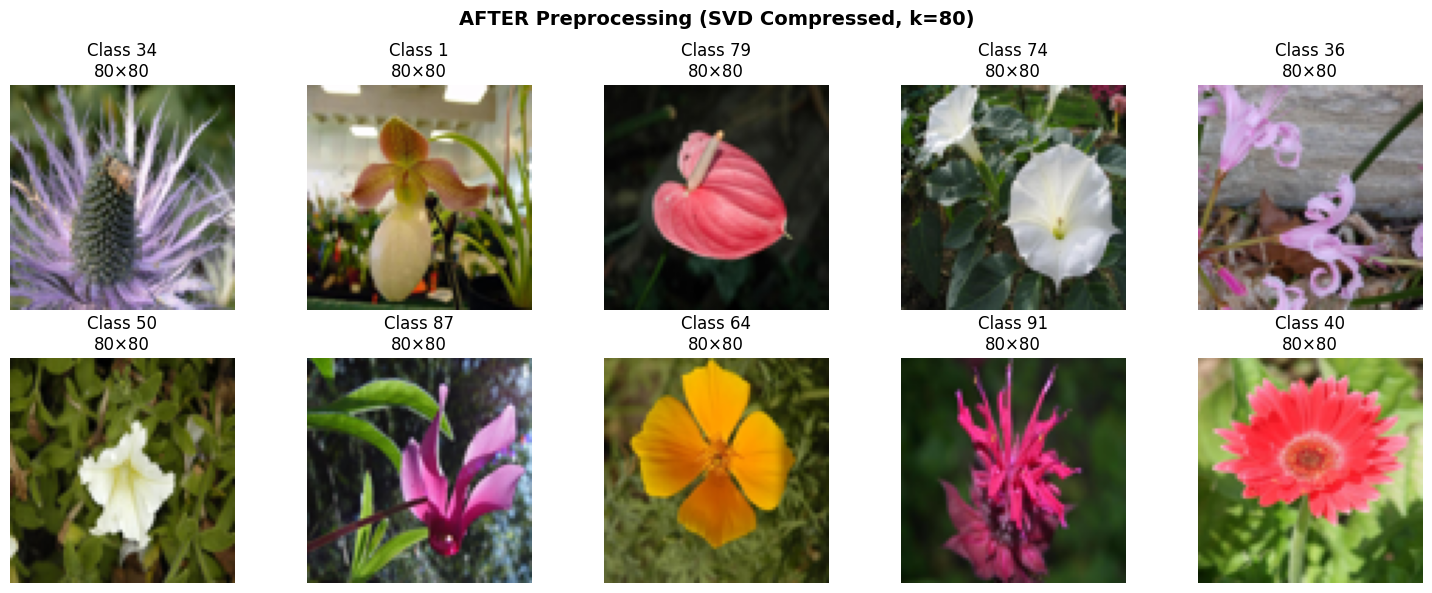

Processed image properties:
  - Standardized size: 80×80 (derived from k=80)
  - SVD compressed: A = U_k × Σ_k × V_T_k
  - Features per image: 19200


In [64]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Use same random indices for comparison
for idx, ax in enumerate(axes):
    img_idx = random_indices[idx]
    # Reshape flattened image back to (k, k, 3)
    img = X_train_svd[img_idx].reshape(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    # Normalize to 0-1 for display
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(f"Class {y_train[img_idx]}\n{IMAGE_SIZE[0]}×{IMAGE_SIZE[1]}")
    ax.axis('off')

plt.suptitle(f"AFTER Preprocessing (SVD Compressed, k={k})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Processed image properties:")
print(f"  - Standardized size: {IMAGE_SIZE[0]}×{IMAGE_SIZE[1]} (derived from k={k})")
print(f"  - SVD compressed: A = U_k × Σ_k × V_T_k")
print(f"  - Features per image: {IMAGE_SIZE[0] * IMAGE_SIZE[1] * 3}")

# Model 3: Convolutional Neural Network

In [83]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch import optim
from tqdm import tqdm

In [87]:
def prepare_for_cnn(X, y):
    """Reshape flattened SVD images to CNN format (N, C, H, W)."""
    # Reshape from (N, k*k*3) to (N, k, k, 3)
    X_reshaped = X.reshape(-1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    # Convert to (N, 3, k, k) - PyTorch expects channels first
    X_reshaped = np.transpose(X_reshaped, (0, 3, 1, 2))
    # Normalize to [0, 1]
    X_reshaped = (X_reshaped - X_reshaped.min()) / (X_reshaped.max() - X_reshaped.min())
    # Convert to tensors
    X_tensor = torch.FloatTensor(X_reshaped)
    y_tensor = torch.LongTensor(y)
    return X_tensor, y_tensor

# Prepare data
X_train_tensor, y_train_tensor = prepare_for_cnn(X_train_svd, y_train)
X_valid_tensor, y_valid_tensor = prepare_for_cnn(X_valid_svd, y_valid)
X_test_tensor, y_test_tensor = prepare_for_cnn(X_test_svd, y_test)

print(f"X_train_tensor shape: {X_train_tensor.shape}")  # Should be (N, 3, k, k)
print(f"X_valid_tensor shape: {X_valid_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")

# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")
print(f"  Test batches: {len(test_loader)}")

X_train_tensor shape: torch.Size([6552, 3, 80, 80])
X_valid_tensor shape: torch.Size([818, 3, 80, 80])
X_test_tensor shape: torch.Size([819, 3, 80, 80])

DataLoaders created:
  Train batches: 205
  Valid batches: 26
  Test batches: 26


In [ ]:
class CNN(nn.Module):
    def __init__(self, input_size, in_channels=3, num_classes=102):
        super(CNN, self).__init__()
        
        # Conv blocks with Batch Normalization
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout_conv = nn.Dropout2d(0.25)  # Dropout for conv layers
        
        # Calculate FC size
        fc_size = input_size // 8
        
        self.fc1 = nn.Linear(128 * fc_size * fc_size, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout_conv(x)
        
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)
        
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout_conv(x)
        
        x = x.reshape(x.shape[0], -1)
        x = self.dropout(F.relu(self.bn_fc(self.fc1(x))))
        x = self.fc2(x)
        return x

In [89]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN(input_size=k, in_channels=3, num_classes=102).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler - reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

num_epochs = 30  # More epochs since we have early stopping

In [91]:

best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        data = data.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data, targets in valid_loader:
            data = data.to(device)
            targets = targets.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()
    
    val_acc = 100. * val_correct / val_total
    
    # Step scheduler based on validation accuracy
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"  ↓ Learning rate reduced: {old_lr} → {new_lr}")
    
    print(f"  Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
    # Early stopping check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ New best model saved! (Val Acc: {val_acc:.2f}%)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠️ Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

# Load best model for evaluation
model.load_state_dict(torch.load('best_model.pth'))

Epoch 1/30: 100%|██████████| 205/205 [00:18<00:00, 11.38it/s]


  Loss: 3.9219 | Train Acc: 10.07% | Val Acc: 23.11%
  ✓ New best model saved! (Val Acc: 23.11%)


Epoch 2/30: 100%|██████████| 205/205 [00:17<00:00, 11.50it/s]


  Loss: 3.2326 | Train Acc: 19.49% | Val Acc: 29.34%
  ✓ New best model saved! (Val Acc: 29.34%)


Epoch 3/30: 100%|██████████| 205/205 [00:17<00:00, 11.52it/s]


...

  Loss: 0.4649 | Train Acc: 86.54% | Val Acc: 56.97%


Epoch 20/30: 100%|██████████| 205/205 [00:18<00:00, 11.36it/s]


  Loss: 0.4049 | Train Acc: 88.31% | Val Acc: 57.09%


Epoch 21/30:  68%|██████▊   | 140/205 [00:12<00:05, 10.95it/s]


KeyboardInterrupt: 

In [79]:
from torchmetrics import Accuracy

acc_metric = Accuracy(task="multiclass", num_classes=102).to(device)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        acc_metric.update(preds, labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = acc_metric.compute()
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print("\n⚠️ Note: Test labels are placeholders (all zeros).")

Testing: 100%|██████████| 26/26 [00:00<00:00, 34.95it/s]


Test Accuracy: 0.24%

⚠️ Note: Test labels are placeholders (all zeros).
